# The Veteran Is Harsher

The three findings so far have been about *when* and *how* people review — the moment they hit submit, the words they choose. This last one is about *who* is doing the reviewing.

Steam attaches to every review a rough measure of the reviewer's experience: how many games they own. Someone with a thousand-game library has simply seen more of what the medium offers than someone on their fifth purchase — and that experience, it turns out, shows up in the scores.

The pattern is real but modest, and it comes wrapped in caveats, so it's worth stating plainly rather than dressing up: **among reviewers whose libraries are public, larger collections recommend games slightly less often than smaller ones.** The effect is a handful of percentage points per tier — not a chasm — but it runs cleanly from the smallest libraries to the largest, and it holds within games as consistently as our sharper findings. The more games you've played, the more you have to compare against, and the higher the bar a new one must clear.

This is the report's most hedged finding, and deliberately so. Before the numbers, three honest limits on what "games owned" can tell us — because a measure this rough deserves them.

In [4]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import _style
_style.set_style()

reviews = pd.read_parquet("../data/processed/reviews.parquet")

# Caveat 1: num_games_owned == 0 is Steam's privacy default (private profile),
# not a real library of zero. Restrict to public profiles.
public = reviews[reviews["num_games_owned"] >= 1].copy()

print(f"all reviews:            {len(reviews):,}")
print(f"public-profile reviews: {len(public):,} ({len(public)/len(reviews):.0%}) — used in this chapter")
print(f"excluded (private = 0): {(reviews['num_games_owned']==0).sum():,} ({(reviews['num_games_owned']==0).mean():.0%})")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
all reviews:            298,553
public-profile reviews: 138,571 (46%) — used in this chapter
excluded (private = 0): 159,982 (54%)


**Three limits, stated before the finding rather than after.**

1. **Public profiles only.** When a Steam profile is private, the API reports zero games owned — and more than half of all reviews come back that way. "Zero" means "hidden," not "owns nothing," so those reviews are excluded. This chapter rests on the **46% of reviews from public profiles**, where the library count is real.

2. **Library size is a blunt proxy.** Ideally we'd distinguish a reviewer's *purchased* library from their total one — paying for two hundred games reflects a deliberate, sustained investment in the medium that a large free or gifted library may not, and it's that invested experience we'd expect to raise standards. Steam exposes only a single ownership count per reviewer, not its composition, so we cannot separate the two. The finding rests on total library size, read as a rough proxy for experience rather than a precise one.

3. **Measured now, not then.** The count is the reviewer's library when we collected the data, not when they wrote the review — libraries only grow, so this adds noise. As elsewhere, the within-game test guards against it: it compares reviewers of the same game, over the same span.

None of these is fatal, but together they're why this finding is offered as a modest, supporting one. With that said — the pattern.

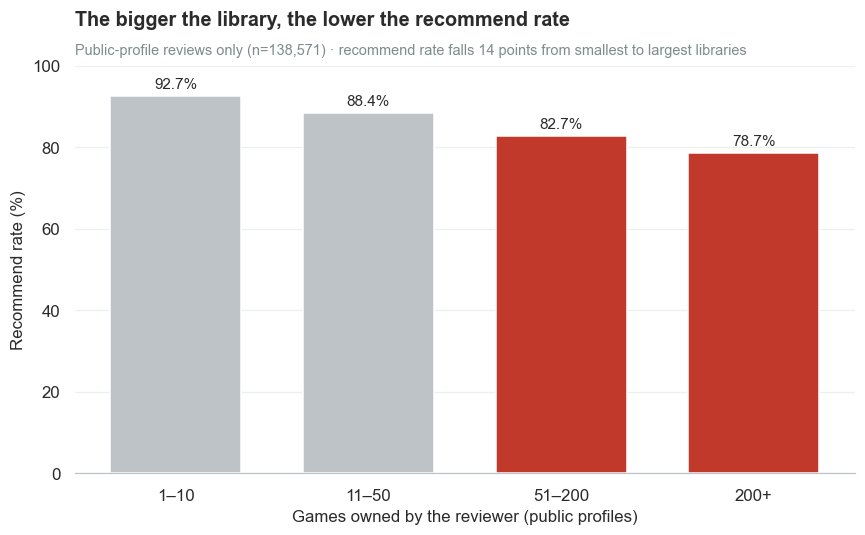

     1–10: 92.7%  (n=8,465)
    11–50: 88.4%  (n=36,993)
   51–200: 82.7%  (n=58,230)
     200+: 78.7%  (n=34,883)


In [5]:
# The gradient: recommend rate by library size (public profiles only)
bins = [1, 10, 50, 200, np.inf]
labels = ["1–10", "11–50", "51–200", "200+"]
public["lib_bucket"] = pd.cut(public["num_games_owned"], bins=bins, labels=labels, right=False)

grad = public.groupby("lib_bucket", observed=True)["voted_up"].agg(["mean", "size"])
grad["rate"] = grad["mean"] * 100

# the largest-library tiers are "the finding" (harsher) -> accent; smaller -> grey
colors = [_style.GREY, _style.GREY, _style.ACCENT, _style.ACCENT]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(grad.index.astype(str), grad["rate"], color=colors, width=0.68)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=10, color=_style.INK)
ax.set_ylim(0, 100)
ax.set_ylabel("Recommend rate (%)")
ax.set_xlabel("Games owned by the reviewer (public profiles)")
ax.set_title("The bigger the library, the lower the recommend rate\n", loc="left",
             fontsize=13, fontweight="bold")
ax.text(0, 1.02,
        f"Public-profile reviews only (n={len(public):,}) · recommend rate falls "
        f"{grad['rate'].iloc[0]-grad['rate'].iloc[-1]:.0f} points from smallest to largest libraries",
        transform=ax.transAxes, fontsize=9.5, color=_style.GREY_DARK, va="bottom")
plt.show()

for b in labels:
    r = grad.loc[b]
    print(f"  {b:>7}: {r['rate']:.1f}%  (n={int(r['size']):,})")

## Two explanations, and a test that separates them

A gradient like this invites two readings, and they're genuinely different. One is **standards** — more games played means more to compare against, and a higher bar. The other is **selection** — a player with the means and appetite for a huge library tries everything, including the bad, while a ten-game owner has bought only the sure things. Under selection, big-library reviewers aren't harsher *people*; they're just reviewing worse *games*. The pooled numbers above cannot tell these apart.

The within-game test can. If selection were the whole story, the effect should vanish when we compare reviewers *of the same game* — because then everyone is rating the same quality, and "which games you choose" can no longer create a gap. So we ask, inside each game: are its large-library reviewers harder to please than its small-library ones?

43 of 47 games show large-library reviewers harsher · median gap 5.5 pts


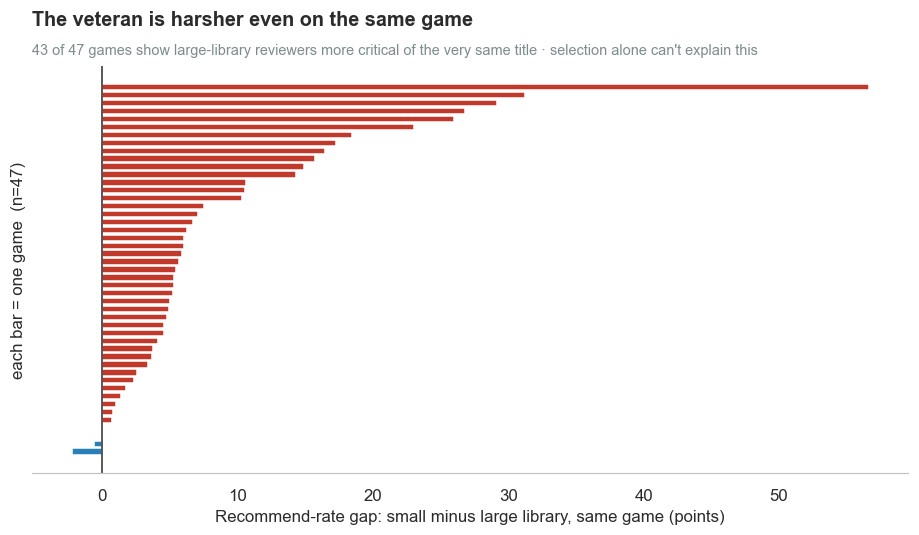

In [6]:
# Within-game mechanism test: small (<50) vs large (>=200) library, same game
def lib_gap(d):
    small = d[(d["num_games_owned"] >= 1) & (d["num_games_owned"] < 50)]
    big   = d[d["num_games_owned"] >= 200]
    if len(small) >= 30 and len(big) >= 30:
        return (small["voted_up"].mean() - big["voted_up"].mean()) * 100  # +ve = big harsher
    return None

gaps = reviews.groupby("app_id").apply(lib_gap, include_groups=False).dropna()
n_games = len(gaps)
n_consistent = (gaps > 0).sum()
print(f"{n_consistent} of {n_games} games show large-library reviewers harsher · "
      f"median gap {gaps.median():.1f} pts")

fig, ax = plt.subplots(figsize=(8.5, 5))
order = gaps.sort_values()
colors = [_style.ACCENT if g > 0 else _style.COUNTER for g in order]
ax.barh(range(len(order)), order.values, color=colors, height=0.8)
ax.axvline(0, color=_style.INK, linewidth=1)
ax.set_yticks([])
ax.set_xlabel("Recommend-rate gap: small minus large library, same game (points)")
ax.set_ylabel(f"each bar = one game  (n={n_games})")
ax.set_title("The veteran is harsher even on the same game\n", loc="left",
             fontsize=13, fontweight="bold")
ax.text(0, 1.02,
        f"{n_consistent} of {n_games} games show large-library reviewers more critical of the very same title · "
        f"selection alone can't explain this",
        transform=ax.transAxes, fontsize=9.5, color=_style.GREY_DARK, va="bottom")
plt.show()

## What it means

Across 43 of 47 games, reviewers with large libraries are more critical of the *same game* than reviewers with small ones — by a median of about five and a half points. The gap is modest, and the caveats are real: this is public profiles only, library size is a blunt proxy, and the count is measured after the fact. But the direction is consistent, and the within-game test does something the pooled gradient alone could not — it rules out the simplest competing explanation.

That explanation was selection: perhaps big-library players, with the means to try everything, simply review more bad games, while ten-game owners stick to sure things. It's a real effect, and it surely contributes. But it cannot be the whole story, because it should disappear once the game is held fixed — and it doesn't. **Even reviewing the identical title, the player with hundreds of games behind them is harder to please.**

**Experience raises the bar.** The more of a medium you've seen, the less easily a new entry impresses you — a pattern familiar to any film critic, any longtime reader, any veteran of any art form, now visible in two hundred thousand Steam reviews. It is the gentlest of our four findings, but it rests on the same foundation as the rest: not what the aggregate score says, but what structure hides beneath it — here, the simple fact that the same game earns a different verdict depending on who is holding the controller.